In [5]:
import os
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path: sys.path.append(module_path)
import unify_lib as uni

import time
import pandas as pd
from pprint import pprint
import ytmusicapi as ytmusicapi
from fuzzywuzzy import fuzz
import re
DATE = time.strftime('%m-%d-%Y')
print(DATE)
PLAYLIST_MAX_SIZE=5000

MIN_ALBUM_LEN = 3
ALBUM_LIKE_MIN_PROBA = 0.7

MB_LIB = '../db_assets/musicbee_library.tsv'
MB_INBOX = '../db_assets/musicbee_inbox.tsv'
YT_TRACK_DB = '../../ytmusic/playlists/_tracks_db.tsv'
HEADER_FILE='../../ytmusic/headers_auth.json'
MB_LIB_LIKE_M3U=f'../m3u/musicbee_library_thumbs_up_from_ytmusic_{DATE}.m3u'
MB_DLD_LIKE_M3U=f'../m3u/musicbee_downloads_thumbs_up_from_ytmusic_{DATE}.m3u'

yt_res_cache = {}
yt_unmatched_cache = {}
yt_album_track_cache = {}



04-01-2023


## Load musicbee and ytmusic databases

In [6]:
print('YTMUSIC')
print(f'Using ytmusicapi version: {ytmusicapi.__version__}')
print(f'Using header file: {HEADER_FILE}')
yt = ytmusicapi.YTMusic(HEADER_FILE)


print(f'Using yt db file: {YT_TRACK_DB}')
yt_db = pd.read_csv(YT_TRACK_DB, sep='\t', index_col=0)
print(f"Loaded {len(yt_db)} ytmusic db entries.")

## library
print('\nMUSICBEE LIBRARY')
print(f'Using musicbee db file: {MB_LIB}')
mb_lib = pd.read_csv(MB_LIB, sep='\t')
mb_lib['fuzzy_id'] = mb_lib.apply(uni.make_musicbee_fuzzy_id, axis=1)
mb_lib['fuzzy_album_id'] = mb_lib.apply(uni.make_mb_fuzzy_album_id, axis=1)
mb_lib = mb_lib.loc[~mb_lib['Path'].str.endswith('.asx')]  # ignore asx files
print(f"Loaded {len(mb_lib)} musicbee db entries.")

## inbox
print('\nMUSICBEE INBOX')
print(f'Using musicbee db file: {MB_INBOX}')
mb_inb = pd.read_csv(MB_INBOX, sep='\t')
mb_inb['fuzzy_id'] = mb_inb.apply(uni.make_musicbee_fuzzy_id, axis=1)
mb_inb['fuzzy_album_id'] = mb_inb.apply(uni.make_mb_fuzzy_album_id, axis=1)
mb_inb = mb_inb.loc[~mb_inb['Path'].str.endswith('.asx')]  # ignore asx files
print(f"Loaded {len(mb_inb)} musicbee db entries.")

# downloads subset
print('\nMUSICBEE DOWNLOADS')
mb_dld = mb_inb.loc[mb_inb['Path'].str.contains('Downloads')]
print(f"Loaded {len(mb_dld)} musicbee db entries.")


YTMUSIC
Using ytmusicapi version: 0.25.0
Using header file: ../../ytmusic/headers_auth.json
Using yt db file: ../../ytmusic/playlists/_tracks_db.tsv
Loaded 146118 ytmusic db entries.

MUSICBEE LIBRARY
Using musicbee db file: ../db_assets/musicbee_library.tsv
Loaded 55531 musicbee db entries.

MUSICBEE INBOX
Using musicbee db file: ../db_assets/musicbee_inbox.tsv
Loaded 42092 musicbee db entries.

MUSICBEE DOWNLOADS
Loaded 4857 musicbee db entries.


## Organize musicbee albums

In [7]:
# Build database of musicbee albums
def get_album_dict(df):
  # most of these take the most common value for all tracks in album
  album_dict = {
    'album_artist': pd.concat([df['Artist'], df['Album Artist']]).value_counts().index[0],
    'album': df['Album'].value_counts().index[0],
    'year': uni.parse_mb_year(df['Year'].value_counts().index[0]),
    'rating_mean': round(df['Rating'].sum()/len(df), 2),
    'like_probability': round(len(df['Rating'].loc[df['Rating'] > 3])/len(df['Rating']), 2), 
    'total_track_playcount': df['Play Count'].sum(), 
    'total_tracks': len(df), 
    'genre': ''
  }
  if len(df['Genre'].dropna()): # some albums dont have genre
    album_dict['genre'] = df['Genre'].value_counts().index[0]
  return album_dict

# LIBRARY
mb_lib_album_data = {}
for album_id, df in mb_lib.groupby('fuzzy_album_id'):
  if len(df) < MIN_ALBUM_LEN:
    continue
  mb_lib_album_data[album_id] = get_album_dict(df)
  
mb_lib_album_data = pd.DataFrame(mb_lib_album_data).T
# mb_dld_album_data.sample(10)

# DOWNLOADS
mb_dld_album_data = {}
for album_id, df in mb_dld.groupby('fuzzy_album_id'):
  if len(df) < MIN_ALBUM_LEN:
    continue
  try:
    mb_dld_album_data[album_id] = get_album_dict(df)
  except Exception as e:
    # print(album_id, e)
    # print(df)
    pass
mb_dld_album_data = pd.DataFrame(mb_dld_album_data).T
# mb_dld_album_data.sample(10)

## Library: Search ytmusic for musicbee albums and fuzz check matches

In [4]:
lib_matched_entries = []
lib_unmatched_entries = []
for i, (album_key, album) in enumerate(mb_lib_album_data.iterrows()):
    prog = f'({i}/{len(mb_lib_album_data)})'
    # Check cache for saved YTMusic query response or previous match failures        
    if album_key in yt_res_cache:
        match = yt_res_cache[album_key]
    elif album_key in yt_unmatched_cache:
        print(f'Skipping: previously unmatched album: {album_key}')
        continue
    # Query YTMusic
    else:
        match = album.to_dict()
        album_query = f'{album.album_artist} - {album.album}'
        # if album.year: album_query += f' {album.year}'
        try:
            # print(f'searching for {album_query}')
            res = yt.search(query=album_query, filter='albums', limit=1)
            if len(res):
                res = res[0]
                match['is_album'] = True
                match['ytmusic_title'] = ''
                match['ytmusic_album'] = res.get('title', '')
                match['ytmusic_albumId'] = res.get('browseId', '')
                if 'artists' in res:
                    match['ytmusic_artist'] = res['artists'][0].get('name', '')
                    match['ytmusic_artistId'] = res['artists'][0].get('id', '')
                match['ytmusic_key'] = f"{match.get('ytmusic_artist', '').lower()} - {match.get('ytmusic_album', '')}"
            
        except Exception as e:
            print(f'Error with query {album_query}: {e}')
            pass

        # Store unmatched ytmusic query
        if len(res) == 0:
            unmatch = album.to_dict()
            unmatch['manual_label'] = 'no-match'
            yt_unmatched_cache[album_key] = unmatch
            lib_unmatched_entries.append(unmatch)
            print(f'Skipping unmatched: {album_query}')
            continue

        # Other ytmusic fields
        # match['ytmusic_entry'] = f"{match.get('ytmusic_artist', '')} - {match.get('ytmusic_title', '')} - {match.get('ytmusic_album', '')}"
        match['ytmusic_duration'] = res['duration']
        match['ytmusic_year'] = res['year']
        match['ytmusic_resultType'] = res['resultType']
        yt_res_cache[album_key] = match

    # Musicbee fields
    match['musicbee_key'] = album_key
    match['manual_label'] = f'no-label_{DATE}'

    # Match Score
    try:
        scores = uni.extract_match_scores(
            match['musicbee_key'], match['ytmusic_key'])
        for sk, sv in scores.items():
            match[f'match_score_{sk}'] = sv
        # Using manual grading to set thresholds
        if scores['token_sort_ratio'] < 40 or scores['token_set_ratio'] < 60:
            match['match_quality'] = 0.
        elif scores['token_sort_ratio'] > 75 or scores['token_set_ratio'] > 75:
            match['match_quality'] = 1.
        else:
            match['match_quality'] = 0.5
    except Exception as e:
        match['match_quality'] = 0.0
        print(f'Skipping match score for {album_query}.\n  Match Error: {e}')

    # Update match results
    lib_matched_entries.append(match)
    print(f"{prog} {match['match_quality']} match for {album_query}\ttoken_sort_ratio={scores['token_sort_ratio']}\ttoken_set_ratio={scores['token_set_ratio']}")

# Process Matched entries
lib_match_df = pd.DataFrame(lib_matched_entries)
lib_match_file = f'../logs/musicbee_library_yt_album_matches_{DATE}.tsv'
lib_match_df.to_csv(lib_match_file, sep='\t', header=True)

# Process Unmatched entries
lib_unmatch_df = pd.DataFrame(lib_unmatched_entries)
lib_unmatch_file = f'../logs/musicbee_library_yt_album_failed_matches_{DATE}.tsv'
lib_unmatch_df.to_csv(lib_unmatch_file, sep='\t', header=True)


(0/4457) 0.0 match for 高中正義 - All Of Me	token_sort_ratio=26	token_set_ratio=26
(1/4457) 1.0 match for 高中正義 - An Insatiable High	token_sort_ratio=65	token_set_ratio=100
(2/4457) 0.0 match for †‡† - CDR	token_sort_ratio=17	token_set_ratio=100
(3/4457) 0.0 match for シートベルツ - COWBOY BEBOP	token_sort_ratio=35	token_set_ratio=100
(4/4457) 0.0 match for 久石譲 - Princess Mononoke: Image Album	token_sort_ratio=21	token_set_ratio=21
(5/4457) 0.0 match for 福居良トリオ - SCENERY	token_sort_ratio=0	token_set_ratio=0
(6/4457) 1.0 match for ∆ ∆ - Skyway	token_sort_ratio=100	token_set_ratio=100
(7/4457) 1.0 match for 芸能山城組 - Symphonic Suite AKIRA	token_sort_ratio=56	token_set_ratio=100
(8/4457) 0.0 match for 高中正義 - The Rainbow Goblins	token_sort_ratio=25	token_set_ratio=25
(9/4457) 0.0 match for Θανάσης Παπακωνσταντίνου - Βραχνός προφήτης	token_sort_ratio=4	token_set_ratio=4
(10/4457) 1.0 match for 水曜日のカンパネラ - トライアスロン	token_sort_ratio=58	token_set_ratio=100
(11/4457) 1.0 match for !!! - THR!!!ER	token_sort_r

In [ ]:
# Merge previous manual ratings with current
last_grade = '../logs/musicbee_library_yt_album_matches_10-23-2022_graded.tsv'
lib_match_df_graded = pd.read_csv(last_grade, sep='\t', index_col=0)
lib_match_df_graded['grade'] = lib_match_df_graded['Unnamed: 24']
lib_match_df_graded = lib_match_df_graded.drop('Unnamed: 24', axis=1)
lib_match_df_graded['match_key'] = lib_match_df_graded['ytmusic_key'] + '__' + lib_match_df_graded['ytmusic_albumId']

# Update resace csv with older grades
lib_match_df['match_key'] = lib_match_df['ytmusic_key'] + '__' + lib_match_df['ytmusic_albumId']
lib_match_df_new_graded = lib_match_df.set_index('match_key', drop=False).join(lib_match_df_graded.set_index('match_key')['grade'], how='left')

# Process Matched entries
lib_match_file = f'../logs/musicbee_library_yt_album_matches_partial_graded_{DATE}.tsv'
lib_match_df_new_graded.to_csv(lib_match_file, sep='\t', header=True)

## Library: Manually rank matches before next steps

In [111]:
tsv_date =  '04-01-2023' # '10-23-2022'
# Process Matched entries
lib_match_df_graded = pd.read_csv(f'../logs/musicbee_library_yt_album_matches_graded_{tsv_date}.tsv', sep='\t', index_col=0)
if tsv_date == '10-23-2022': # fixed in more recent
  lib_match_df_graded['grade'] = lib_match_df_graded['Unnamed: 24']
  lib_match_df_graded = lib_match_df_graded.drop('Unnamed: 24', axis=1)
lib_match_df = lib_match_df_graded.loc[lib_match_df_graded.grade == 'ok']
lib_match_file = f'../logs/musicbee_library_yt_album_matches_{tsv_date}.tsv'
lib_match_df.to_csv(lib_match_file, sep='\t', header=True)
print(f'Matched {len(lib_match_df)} albums')
# N=50
# lib_match_df['genre_main'].value_counts().head(N).plot.bar(figsize=(20, 4), title='Top {N} main genres')

if tsv_date == '10-23-2022': # didnt have 'up grade inmore recent
  # Process Need Upload entries
  lib_need_upload = lib_match_df_graded.loc[lib_match_df_graded.grade == 'up']
  lib_upload_file = f'../logs/musicbee_library_yt_album_need_to_upload_{tsv_date}.tsv'
  lib_need_upload.to_csv(lib_upload_file, sep='\t', header=True)
  print(f'Need to upload {len(lib_need_upload)} albums') # Need to upload 154 albums

# Process Unmatched entries
lib_unmatch_df = pd.read_csv(f'../logs/musicbee_library_yt_album_failed_matches_{tsv_date}.tsv', sep='\t', index_col=0)
lib_unmatch_df = pd.concat([lib_unmatch_df, lib_match_df_graded.loc[lib_match_df_graded.grade == 'x']])
lib_unmatch_file = f'../logs/musicbee_library_yt_album_failed_matches_all_{tsv_date}.tsv'
lib_unmatch_df.drop_duplicates().to_csv(lib_unmatch_file, sep='\t', header=True)
print(f'Unable to match {len(lib_unmatch_df.drop_duplicates())} albums')



Matched 4100 albums
Unable to match 993 albums


## Library: Process Matches add to ytmusic library and playlists

In [1]:
print(f"Number of albums > {ALBUM_LIKE_MIN_PROBA} like probability: {len(mb_lib_album_data['like_probability'].loc[mb_lib_album_data['like_probability'] > ALBUM_LIKE_MIN_PROBA])}")
yt_library_album_matches = []
yt_library_tracks = []
yt_library_album_liked = []
mb_library_album_need_like = []
lib_year_playlists  = {}
lib_top_albums_playlist = []
for i, (alb_i, album) in enumerate(lib_match_df.iterrows()):
    
    # Format current album dict
    album['liked_album'] = bool(album['like_probability'] > ALBUM_LIKE_MIN_PROBA)
    album['genre_main'] = str(album['genre']).split(';')[0]
    album['year_playlist'] = uni.get_album_year_playlist(album['year'])
    if album['year_playlist'] not in lib_year_playlists:
        lib_year_playlists[album['year_playlist']] = []
    album['musicbee_tracks'] = []
    album['ytmusic_tracks'] = []

    # Get ytmusic album entry
    if album['ytmusic_albumId'] in yt_album_track_cache:
        yt_album = yt_album_track_cache[album['ytmusic_albumId']]
    else:
        yt_album = yt.get_album(album['ytmusic_albumId'])['tracks']
        yt_album_track_cache[album['ytmusic_albumId']] = yt_album
    
    # Get musicbee album entry
    mb_album = mb_lib.loc[mb_lib['fuzzy_album_id'] == album['musicbee_key']].copy()
    mb_ids = mb_album.apply(uni.make_musicbee_fuzzy_track_id, axis=1)
    mb_album['fuzzy_track_id'] = mb_ids

    # Loop through album tracks
    for yt_track in yt_album:
        yt_track = uni.clean_up_album_track(yt_track)

        # check if mb has match like
        yt_track['fuzzy_track_id'] = uni.get_fuzzy_track_id(yt_track['title'], yt_track['artist'])
        try:
            query, result, score = uni.query_search_pool(yt_track['fuzzy_track_id'], list(mb_ids), scorer=fuzz.ratio)
        except:
            print(f"Error searching mb pool of size {len(mb_ids)} for id: {yt_track['fuzzy_track_id']}")
            continue
        # if score < 0.8: ###############Todo
        #     print(f"Skipping low score: {score} for id: {yt_track['fuzzy_track_id']}")
        #     continue
        mb_track = mb_album.loc[mb_album['fuzzy_track_id'] == result].iloc[0].to_dict()
        
        # TODO if yt liked add to add to prexisting genre playlist based on album['genre_main']
        # Compare musicbee and ytmusic LIKE status
        mb_is_like = bool(mb_track['Rating'] > 3.5)
        yt_is_like = bool(yt_track['likeStatus'] == 'LIKE')
        if not mb_is_like and yt_is_like:
            mb_library_album_need_like.append(mb_track['Path'])
        if mb_is_like and not yt_is_like:
            yt.rate_song(yt_track['videoId'], rating='LIKE')
            yt_library_album_liked.append(yt_track['videoId'])
            lib_year_playlists[album['year_playlist']].append(yt_track['videoId'])
            yt_is_like = True

        if album['liked_album']:
            lib_top_albums_playlist.append(yt_track['videoId'])
        album['musicbee_tracks'].append(mb_track)
        album['ytmusic_tracks'].append(yt_track)
        yt_library_tracks.append(yt_track['videoId'])
        
    prog = f'({i}/{len(lib_match_df)})'
    print(f"{prog} {album['album']} - {album['album_artist']}")
    yt_library_album_matches.append(album)
    
print(f"{len(yt_library_album_matches)} musicbee matches found on ytmusic")



NameError: name 'ALBUM_LIKE_MIN_PROBA' is not defined

In [120]:
DRY = False 

# print(f"{len(mb_library_album_need_like)} NOT liked musicbee matches liked on ytmusic")
# if not DRY:
#     pd.Series(mb_library_album_need_like).dropna().to_csv(MB_LIB_LIKE_M3U, sep='\t', header=False, index=False)

# print(f"{len(yt_library_album_liked)} liked musicbee matches NOT liked on ytmusic")
# if not DRY:
#     yt.create_playlist(
#         title='yy_musicbee_library_albums_need_like',
#         description='musicbee library album tracks liked in musicbee but not in ytmusic',
#         video_ids=yt_library_album_liked
#     )

# print(f"{len(lib_top_albums_playlist)} musicbee matches in ytmusic top albums")
# if not DRY:
#     yt.create_playlist(
#         title='yy_musicbee_library_albums_like',
#         description='musicbee library top albums based on like_probability',
#         video_ids=lib_top_albums_playlist
#     )

# print(f"\n{len(lib_year_playlists)} year playlists with ytmusic matches")
# for year, vids in lib_year_playlists.items():
#     if not len(vids):
#         continue
#     print(f" {len(vids)} (year {year}) musicbee matches in ytmusic")
#     if not DRY:
#         yt.create_playlist(
#             title=f'yy_{year}_musicbee_library_albums_like',
#             description=f'{year} musicbee library albums with {len(vids)} tracks',
#             video_ids=vids
#         )
    

print(f"\n{len(yt_library_tracks)} matched ytmusic library tracks, making library playlists of size {PLAYLIST_MAX_SIZE}")
for i, start in enumerate(range(0, len(yt_library_tracks), PLAYLIST_MAX_SIZE)):
    end = min(start+PLAYLIST_MAX_SIZE, len(yt_library_tracks))
    vids = yt_library_tracks[start:end]
    print(f" {i+1} {start}:{end} musicbee library album tracks")
    if not DRY:
        yt.create_playlist(
            title=f'yyz_musicbee_library_albums_part_{i+1}',
            description=f'part {i} for musicbee library album tracks',
            video_ids=vids
        )



51458 matched ytmusic library tracks, making library playlists of size 5000
 1 0:5000 musicbee library album tracks


Exception: Server returned HTTP 400: Bad Request.
You are creating too many playlists. Please wait a while before creating further playlists.

## Downloads: Search ytmusic for musicbee albums and fuzz check matches

In [8]:
dld_matched_entries = []
dld_unmatched_entries = []
for i, (album_key, album) in enumerate(mb_dld_album_data.iterrows()):
    prog = f'({i}/{len(mb_dld_album_data)})'
    # Check cache for saved YTMusic query response or previous match failures        
    if album_key in yt_res_cache:
        match = yt_res_cache[album_key]
    elif album_key in yt_unmatched_cache:
        print(f'Skipping: previously unmatched album: {album_key}')
        continue
    # Query YTMusic
    else:
        match = album.to_dict()
        album_query = f'{album.album_artist} - {album.album}'
        # if album.year: album_query += f' {album.year}'
        try:
            # print(f'searching for {album_query}')
            res = yt.search(query=album_query, filter='albums', limit=1)
            if len(res):
                res = res[0]
                match['is_album'] = True
                match['ytmusic_title'] = ''
                match['ytmusic_album'] = res.get('title', '')
                match['ytmusic_albumId'] = res.get('browseId', '')
                if 'artists' in res:
                    match['ytmusic_artist'] = res['artists'][0].get('name', '')
                    match['ytmusic_artistId'] = res['artists'][0].get('id', '')
                match['ytmusic_key'] = f"{match.get('ytmusic_artist', '').lower()} - {match.get('ytmusic_album', '')}"
            
        except Exception as e:
            print(f'Error with query {album_query}: {e}')
            pass

        # Store unmatched ytmusic query
        if len(res) == 0:
            unmatch = album.to_dict()
            unmatch['manual_label'] = 'no-match'
            yt_unmatched_cache[album_key] = unmatch
            dld_unmatched_entries.append(unmatch)
            print(f'Skipping unmatched: {album_query}')
            continue

        # Other ytmusic fields
        # match['ytmusic_entry'] = f"{match.get('ytmusic_artist', '')} - {match.get('ytmusic_title', '')} - {match.get('ytmusic_album', '')}"
        match['ytmusic_duration'] = res['duration']
        match['ytmusic_year'] = res['year']
        match['ytmusic_resultType'] = res['resultType']
        yt_res_cache[album_key] = match

    # Musicbee fields
    match['musicbee_key'] = album_key
    match['manual_label'] = f'no-label_{DATE}'

    # Match Score
    try:
        scores = uni.extract_match_scores(
            match['musicbee_key'], match['ytmusic_key'])
        for sk, sv in scores.items():
            match[f'match_score_{sk}'] = sv
        # Using manual grading to set thresholds
        if scores['token_sort_ratio'] < 40 or scores['token_set_ratio'] < 60:
            match['match_quality'] = 0.
        elif scores['token_sort_ratio'] > 75 or scores['token_set_ratio'] > 75:
            match['match_quality'] = 1.
        else:
            match['match_quality'] = 0.5
    except Exception as e:
        match['match_quality'] = 0.0
        print(f'Skipping match score for {album_query}.\n  Match Error: {e}')

    # Update match results
    dld_matched_entries.append(match)
    print(f"{prog} {match['match_quality']} match for {album_query}\ttoken_sort_ratio={scores['token_sort_ratio']}\ttoken_set_ratio={scores['token_set_ratio']}")

# Process Matched entries
dld_match_df = pd.DataFrame(dld_matched_entries)
dld_match_file = f'../logs/musicbee_downloads_yt_album_matches_{DATE}.tsv'
dld_match_df.to_csv(dld_match_file, sep='\t', header=True)

# Process Unmatched entries
dld_unmatch_df = pd.DataFrame(dld_unmatched_entries)
dld_unmatch_file = f'../logs/musicbee_downloads_yt_album_failed_matches_{DATE}.tsv'
dld_unmatch_df.to_csv(dld_unmatch_file, sep='\t', header=True)

(0/399) 1.0 match for !!! - Strange Weather, Isn't It?	token_sort_ratio=100	token_set_ratio=100
(1/399) 1.0 match for $uicideboy$ - 7th or St. Tammany	token_sort_ratio=100	token_set_ratio=100
(2/399) 1.0 match for 공중도둑 (Mid-Air Thief) - 무너지기 (Crumbling)	token_sort_ratio=90	token_set_ratio=100
(3/399) 1.0 match for μ-Ziq - Challenge Me Foolish	token_sort_ratio=100	token_set_ratio=100
(4/399) 1.0 match for 100 gecs - 10,000 gecs	token_sort_ratio=100	token_set_ratio=100
(5/399) 1.0 match for 21 Savage - i am > i was	token_sort_ratio=100	token_set_ratio=100
(6/399) 1.0 match for 6ix9ine - DUMMY BOY	token_sort_ratio=100	token_set_ratio=100
(7/399) 1.0 match for 6LACK - East Atlanta Love Letter	token_sort_ratio=100	token_set_ratio=100
Skipping unmatched: Ackryte - Realize EP
(9/399) 0.0 match for AFTA-1 - Love Is Real Vol.1	token_sort_ratio=22	token_set_ratio=24
(10/399) 1.0 match for Agent Orange - Living in Darkness	token_sort_ratio=71	token_set_ratio=100
(11/399) 0.0 match for Akufen - My

## Downloads: Manually rank matches before next steps

In [51]:
dld_match_df_graded = pd.read_csv(f'../logs/musicbee_downloads_yt_album_matches_10-31-2022.tsv', sep='\t', index_col=0)

# Process Matched entries
dld_match_df = dld_match_df_graded.loc[dld_match_df_graded['match_quality'] >0.0]
dld_match_df['grade'] = 'ok'
dld_match_file = f'../logs/musicbee_downloads_yt_album_matches.tsv'
dld_match_df.to_csv(dld_match_file, sep='\t', header=True)
print(f'Matched {len(dld_match_df)} albums')

# Process Unmatched entries
dld_unmatch_df = pd.read_csv(f'../logs/musicbee_downloads_yt_album_failed_matches_10-31-2022.tsv', sep='\t', index_col=0)
dld_unmatch_df = pd.concat([dld_unmatch_df, dld_match_df_graded.loc[dld_match_df_graded['match_quality'] == 0.0]])
dld_unmatch_file = f'../logs/musicbee_downloads_yt_album_failed_matches.tsv'
dld_unmatch_df.to_csv(dld_unmatch_file, sep='\t', header=True)
print(f'Unable to match {len(dld_unmatch_df)} albums')


Matched 263 albums
Unable to match 11 albums


/var/folders/b9/mgffxyls38n64v_597j24h6m0000gn/T/ipykernel_42721/3467938667.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dld_match_df['grade'] = 'ok'


## Downloads: Process Matches add to ytmusic playlists

In [59]:
print(f"Number of albums > {ALBUM_LIKE_MIN_PROBA} like probability: {len(mb_dld_album_data['like_probability'].loc[mb_dld_album_data['like_probability'] > ALBUM_LIKE_MIN_PROBA])}")
yt_download_album_matches = []
yt_download_tracks = []
yt_download_album_liked = []
mb_download_album_need_like = []
dld_year_playlists  = {}
dld_top_albums_playlist = []
for i, (alb_i, album) in enumerate(dld_match_df.iterrows()):
    
    # Format current album dict
    album['liked_album'] = bool(album['like_probability'] > ALBUM_LIKE_MIN_PROBA)
    album['genre_main'] = str(album['genre']).split(';')[0]
    album['year_playlist'] = uni.get_album_year_playlist(album['year'])
    if album['year_playlist'] not in dld_year_playlists:
        dld_year_playlists[album['year_playlist']] = []
    album['musicbee_tracks'] = []
    album['ytmusic_tracks'] = []

    # Get ytmusic album entry
    if album['ytmusic_albumId'] in yt_album_track_cache:
        yt_album = yt_album_track_cache[album['ytmusic_albumId']]
    else:
        yt_album = yt.get_album(album['ytmusic_albumId'])['tracks']
        yt_album_track_cache[album['ytmusic_albumId']] = yt_album
    
    # Get musicbee album entry
    mb_album = mb_dld.loc[mb_dld['fuzzy_album_id'] == album['musicbee_key']].copy()
    mb_ids = mb_album.apply(uni.make_musicbee_fuzzy_track_id, axis=1)
    mb_album['fuzzy_track_id'] = mb_ids

    # Loop through album tracks
    for yt_track in yt_album:
        yt_track = uni.clean_up_album_track(yt_track)

        # check if mb has match like
        yt_track['fuzzy_track_id'] = uni.get_fuzzy_track_id(yt_track['title'], yt_track['artist'])
        query, result, score = uni.query_search_pool(yt_track['fuzzy_track_id'], list(mb_ids), scorer=fuzz.ratio)
        mb_track = mb_album.loc[mb_album['fuzzy_track_id'] == result].iloc[0].to_dict()
        
        # TODO if yt liked add to add to prexisting genre playlist based on album['genre_main']
        # Compare musicbee and ytmusic LIKE status
        mb_is_like = bool(mb_track['Rating'] > 3.5)
        yt_is_like = bool(yt_track['likeStatus'] == 'LIKE')
        if not mb_is_like and yt_is_like:
            mb_download_album_need_like.append(mb_track['Path'])
        if mb_is_like and not yt_is_like:
            yt.rate_song(yt_track['videoId'], rating='LIKE')
            yt_download_album_liked.append(yt_track['videoId'])
            dld_year_playlists[album['year_playlist']].append(yt_track['videoId'])
            yt_is_like = True

        if album['liked_album']:
            dld_top_albums_playlist.append(yt_track['videoId'])
        album['musicbee_tracks'].append(mb_track)
        album['ytmusic_tracks'].append(yt_track)
        yt_download_tracks.append(yt_track['videoId'])
        
    prog = f'({i}/{len(dld_match_df)})'
    print(f"{prog} {album['album']} - {album['album_artist']}")
    yt_download_album_matches.append(album)
    
print(f"{len(yt_download_album_matches)} musicbee matches found on ytmusic")



Number of albums > 0.7 like probability: 0
(0/263) Strange Weather, Isn't It? - !!!
(1/263) 7th or St. Tammany - $uicideboy$
(2/263) 무너지기 (Crumbling) - 공중도둑 (Mid-Air Thief)
(3/263) Challenge Me Foolish - μ-Ziq
(4/263) i am > i was - 21 Savage
(5/263) Until the End of Time - 2Pac
(6/263) DUMMY BOY - 6ix9ine
(7/263) East Atlanta Love Letter - 6LACK
(8/263) God Save the Animals - Alex G
(9/263) Blue Rev - Alvvays
(10/263) Big Time - Angel Olsen
(11/263) KiCk i - Arca
(12/263) WE - Arcade Fire
(13/263) Eucalyptus - Avey Tare
(14/263) 10 From 6 - Bad Company
(15/263) Four - Bad Luck
(16/263) Browser - Barbarisms
(17/263) Gallipoli - Beirut
(18/263) A U R O R A - Ben Frost
(19/263) RENAISSANCE - Beyoncé
(20/263) Isles - Bicep
(21/263) The Petrified Forest - Biosphere
(22/263) It's Immaterial - Black Marble
(23/263) Cavalcade - black midi
(24/263) Hellfire - black midi
(25/263) Panic Blooms - Black Moth Super Rainbow
(26/263) No Fear of Time - Black Star
(27/263) Speaking in Tones - Boot Juic

In [63]:
DRY = False 

print(f"{len(mb_download_album_need_like)} NOT liked musicbee matches liked on ytmusic")
if not DRY:
    pd.Series(mb_download_album_need_like).dropna().to_csv(MB_DLD_LIKE_M3U, sep='\t', header=False, index=False)

print(f"{len(yt_download_album_liked)} liked musicbee matches NOT liked on ytmusic")
if not DRY:
    yt.create_playlist(
        title='yy_musicbee_download_albums_need_like',
        description='musicbee download album tracks liked in musicbee but not in ytmusic',
        video_ids=yt_download_album_liked
    )

# print(f"{len(dld_top_albums_playlist)} musicbee matches in ytmusic top albums")
# if not DRY:
#     yt.create_playlist(
#         title='yy_musicbee_download_albums_like',
#         description='musicbee download top albums based on like_probability',
#         video_ids=dld_top_albums_playlist
#     )

print(f"\n{len(dld_year_playlists)} year playlists with ytmusic matches")
for year, vids in dld_year_playlists.items():
    if not len(vids):
        continue
    print(f" {len(vids)} (year {year}) musicbee matches in ytmusic")

    if not DRY:
        yt.create_playlist(
            title=f'yy_{year}_musicbee_download_albums_like',
            description=f'{year} musicbee download albums with {len(vids)} tracks',
            video_ids=vids
        )
    
    
print(f"\n{len(yt_download_tracks)} matched ytmusic download tracks, making playlists of size {PLAYLIST_MAX_SIZE}")
for i, start in enumerate(range(0, len(yt_download_tracks), PLAYLIST_MAX_SIZE)):
    end = min(start+PLAYLIST_MAX_SIZE, len(yt_download_tracks))
    vids = yt_download_tracks[start:end]
    print(f" {i+1} {start}:{end} musicbee download album tracks")
    if not DRY:
        yt.create_playlist(
            title=f'yyz_musicbee_download_albums_part_{i+1}',
            description=f'part {i} for musicbee download album tracks',
            video_ids=vids
        )


96 NOT liked musicbee matches liked on ytmusic
12 liked musicbee matches NOT liked on ytmusic

17 year playlists with ytmusic matches
 1 (year 2015) musicbee matches in ytmusic
 4 (year 2022) musicbee matches in ytmusic
 2 (year 2020) musicbee matches in ytmusic
 1 (year 2017) musicbee matches in ytmusic
 1 (year 2016) musicbee matches in ytmusic
 3 (year 2021) musicbee matches in ytmusic

3234 matched ytmusic download tracks, making playlists of size 5000
 1 0:3234 musicbee download album tracks


## other

In [67]:
# pls = yt.get_library_playlists(limit=1000)
# for p in pls:    
#     if p['title'].startswith('yy_2'): #and 'musicbee_library_albums' in p['title']:
#         print(p['title'])
#         yt.delete_playlist(p['playlistId'])
    

yy_2005s_musicbee_library_albums_like
yy_2010_musicbee_library_albums_like
yy_2010s_musicbee_library_albums_like
yy_2011_musicbee_library_albums_like
yy_2012_musicbee_library_albums_like
yy_2013_musicbee_library_albums_like
yy_2014_musicbee_library_albums_like
yy_2015_musicbee_library_albums_like
yy_2016_musicbee_library_albums_like
yy_2017_musicbee_library_albums_like
yy_2018_musicbee_library_albums_like
yy_2019_musicbee_library_albums_like
yy_2020_musicbee_library_albums_like


## musicbee Album Stats

In [32]:
N=20
print(N,'top genres\n', mb_lib_album_data['genre'].value_counts().head(N))


20 top genres
                     455
Electronic          152
Rock                141
Hip-Hop              86
Jazz                 69
Indie                64
Rap                  60
Hip Hop; Rap         59
Alternative          57
Hip Hop              51
Rap; Hip Hop         47
Blues                41
Indie Rock           38
Soul                 34
Pop                  33
Ambient              30
Psychedelic Rock     23
Dubstep              19
R&B                  19
Rap/Hip Hop          18
Name: genre, dtype: int64


count    4327.000000
mean     2000.886526
std        17.587108
min      1928.000000
25%      1991.000000
50%      2009.000000
75%      2014.000000
max      2022.000000
Name: year, dtype: float64


<AxesSubplot:title={'center':'Library Albums by Year'}, ylabel='Frequency'>

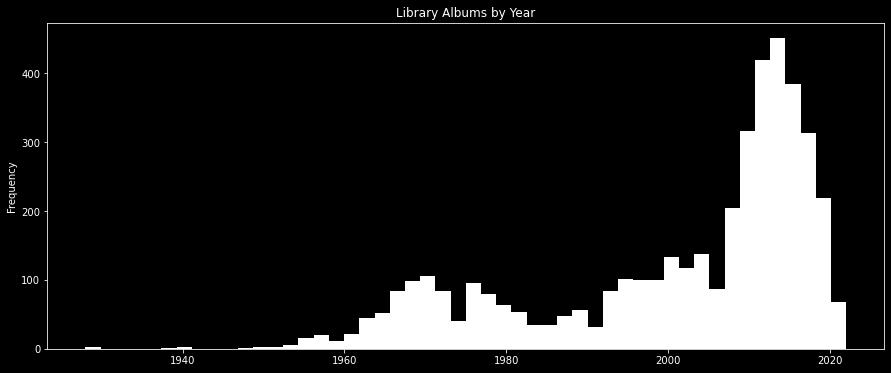

In [127]:
print(mb_lib_album_data['year'].astype(int).describe())
mb_lib_album_data['year'].plot.hist(bins=50, figsize=(15, 6), color='w', title='Library Albums by Year')

count    4327.000000
mean        0.324696
std         0.245240
min         0.000000
25%         0.130000
50%         0.300000
75%         0.500000
max         1.000000
Name: like_probability, dtype: float64


<AxesSubplot:title={'center':'Library Albums by by Like Probability (out of 1)'}, ylabel='Frequency'>

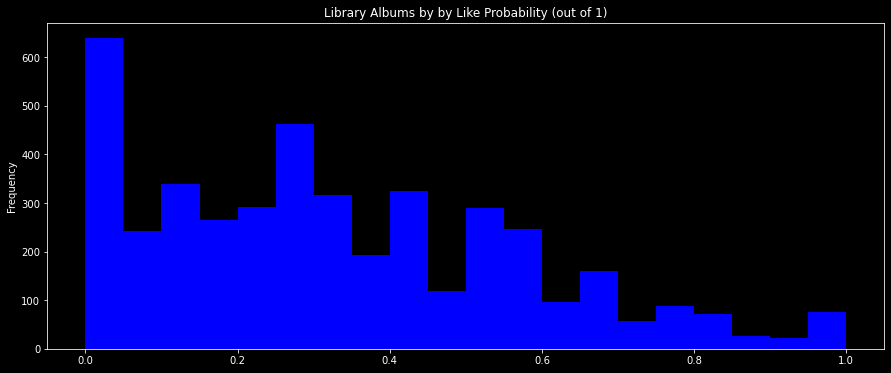

In [100]:
print(mb_lib_album_data['like_probability'].astype(float).describe())
album_data['like_probability'].astype(float).plot.hist(bins=20, figsize=(15, 6), color='b', title='Library Albums by by Like Probability (out of 1)')

In [114]:
mb_lib_album_data['like_probability'].loc[mb_lib_album_data['like_probability'] > 0.5 ]

123mrk - refined madness                                                      0.6
13th floor elevators - the psychedelic sounds of the 13th floor elevators    0.55
20syl - motifs                                                                0.6
a$ap ferg - trap lord                                                        0.62
a.a.l. (against all logic) - a.a.l.                                           1.0
                                                                             ... 
young fathers - cocoa sugar                                                  0.58
young montana? - ymrmxs                                                      0.55
zayyaf - celestial body                                                       0.6
zomby - one foot ahead of the other                                          0.78
zomby - zomby                                                                0.71
Name: like_probability, Length: 892, dtype: object

count    4327.000000
mean        2.207439
std         1.279042
min         0.000000
25%         1.000000
50%         2.750000
75%         3.210000
max         4.670000
Name: rating_mean, dtype: float64


<AxesSubplot:title={'center':'Library Albums by Mean Rating (out of 5)'}, ylabel='Frequency'>

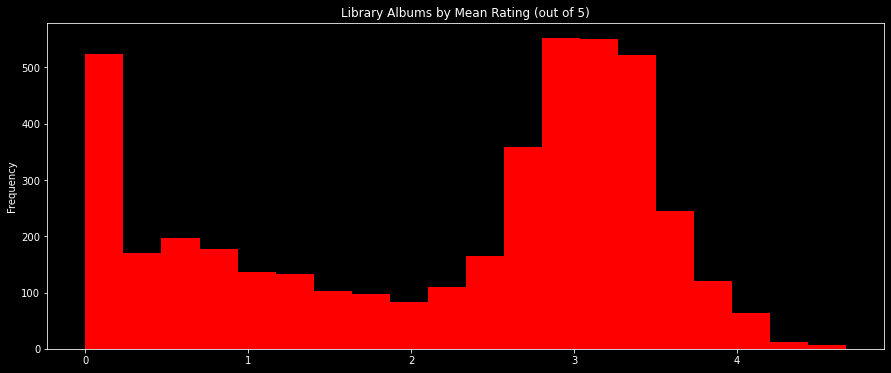

In [120]:
print(mb_lib_album_data['rating_mean'].astype(float).describe())
mb_lib_album_data['rating_mean'].astype(float).plot.hist(bins=20, figsize=(15, 6), color='r', title='Library Albums by Mean Rating (out of 5)')


<AxesSubplot:title={'center':'Library Albums by Playcount Total'}, ylabel='Frequency'>

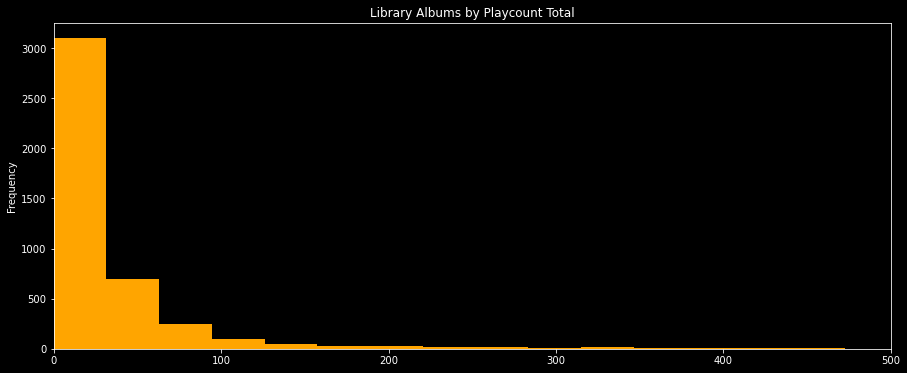

In [121]:
mb_lib_album_data['total_track_playcount'].plot.hist(bins=50, xlim=(0, 500), figsize=(15, 6), color='orange', title='Library Albums by Playcount Total')